In [1]:
import bnlearn as bn

import pandas as pd 
import numpy as np  
import networkx as nx
import itertools
from sklearn.preprocessing import Normalizer, StandardScaler

In [2]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = list(data.columns)
# ANTIGENS = ['V4', 'T4', 'Q4', 'A2', 'N4']  # Only focus on the strong markers. 
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
TIMES = [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
TEST_PROPORTION = 0.25

In [3]:
# Filter the data to OT-1 cells
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       #(data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 4.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

# Normalize the data. 
df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index) 

#TODO: Make the peptide a column so we can put that in the graph and make it the root node for the CL algorithm. 
# https://erdogant.github.io/bnlearn/pages/html/Structure%20learning.html
df = df.reset_index()
cols = MARKERS
cols.append('Peptide')
df = df[MARKERS]


In [4]:
df

Marker,FSC-A,SSC-A,CD25,CD38,Granzyme B,CD2,CD27,CD45RA,CD4,CD86,...,Proliferation,ICOS,IRF8,CD19,MHC-II,CD45,CD44,CX3CR1,CD8a,Peptide
0,-0.650743,-0.532185,3.107598,16.084790,0.776691,-2.169030,1.001913,-6.709430,-3.935002,10.994733,...,1.088990,-3.004475,6.778039,10.195712,3.424442,-6.281301,1.495628,0.909542,-2.732350,N4
1,-0.362056,0.145880,-0.858197,-0.392324,-1.306903,1.093107,0.265950,-0.265064,-0.771762,0.769636,...,0.792030,-1.305328,-0.921440,-0.017533,0.629439,0.137144,0.734844,1.062811,-1.013726,N4
2,0.441740,0.267584,-0.645440,0.159211,-0.826074,-1.279356,-0.538704,-0.132646,-0.571556,1.001147,...,1.018285,-0.574854,-0.798576,-0.880232,-0.228233,-0.712837,1.714071,0.235161,-1.475265,N4
3,1.053078,-0.120710,-0.602889,-0.426795,-0.554837,-1.172899,-0.666271,0.220470,-0.691679,0.538124,...,0.869805,-0.693953,-0.921440,-0.824574,-0.107150,-0.996164,1.683941,0.950414,-1.208058,N4
4,-0.769614,-0.619117,-0.492255,-0.805976,-1.084982,-0.473327,-0.558330,0.198400,0.549592,0.653880,...,0.622339,-1.011551,0.767940,-0.462797,0.437724,-1.595509,-0.666204,-0.010068,-0.971216,N4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6093983,-0.033745,-0.230823,-0.687992,-0.013144,-0.850732,-0.556972,-0.528891,-0.132646,-0.891885,0.422368,...,-0.911953,-0.003179,-0.573325,-0.574113,-0.752926,-0.789117,1.103937,-1.174908,-1.031944,null
6093984,-0.469606,-0.671276,-0.560337,1.606991,-0.887718,-2.039761,-0.371885,1.655004,-0.331310,0.808221,...,0.516282,1.306911,-0.460700,0.038125,-2.185744,0.376882,2.263944,-1.798200,-1.038017,null
6093985,-0.707348,-0.537981,-0.432683,-0.702563,-0.505521,1.229980,-0.617207,-0.574041,0.069100,1.232659,...,0.417295,-1.114770,-1.003349,0.316415,0.518446,0.267911,-0.846985,-0.510745,0.808138,null
6093986,-0.237524,-0.769798,-0.483745,0.503920,-0.764429,0.720509,-0.725148,-0.905087,-0.611597,-0.156411,...,0.636480,-1.154469,-0.747383,-0.017533,0.437724,0.028172,-0.364904,-1.287305,0.474129,null


In [5]:
# Structure learning
model = bn.structure_learning.fit(df, methodtype='cl', scoretype='bic', root_node='Peptide')

[bnlearn] >Computing best DAG using [chow-liu]


Building tree:   0%|          | 0/351.0 [00:00<?, ?it/s]

[bnlearn] >Compute structure scores for model comparison (higher is better).


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


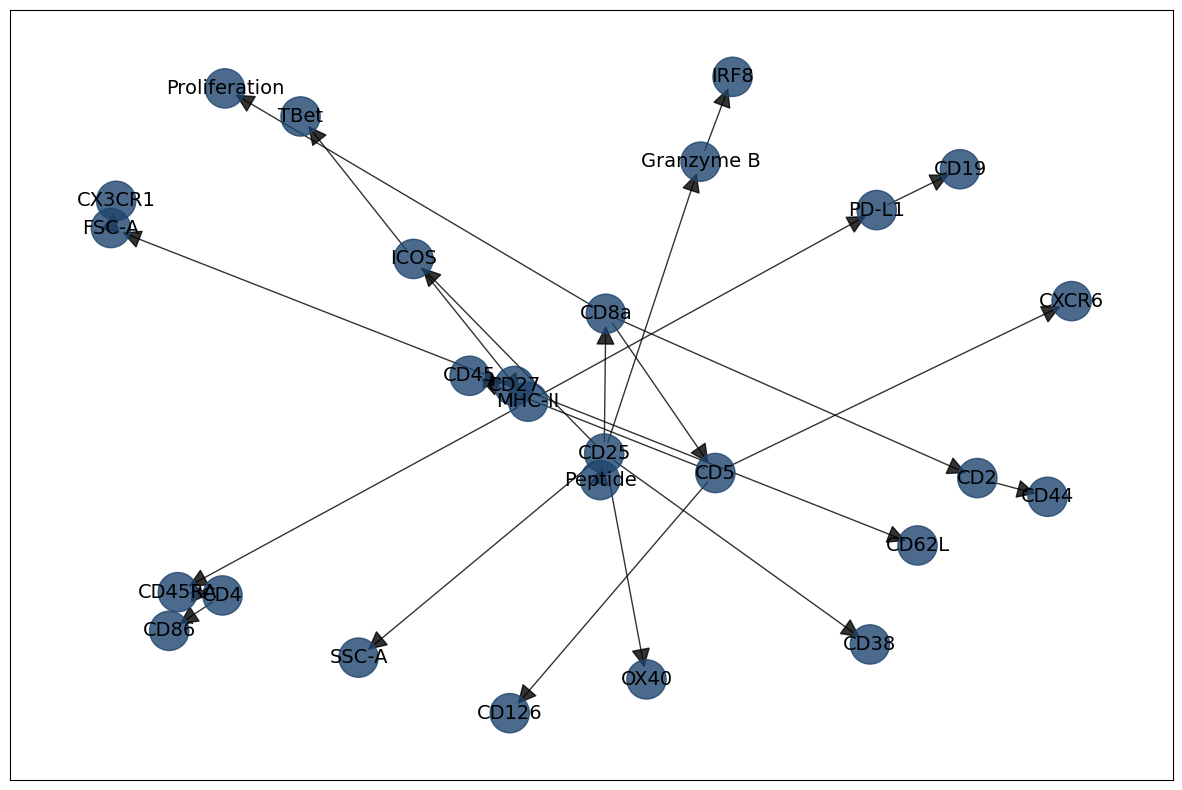

In [6]:
G = bn.plot(model)

[bnlearn] >Compute edge strength with [chi_square]
[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [chi_square] test statistic.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


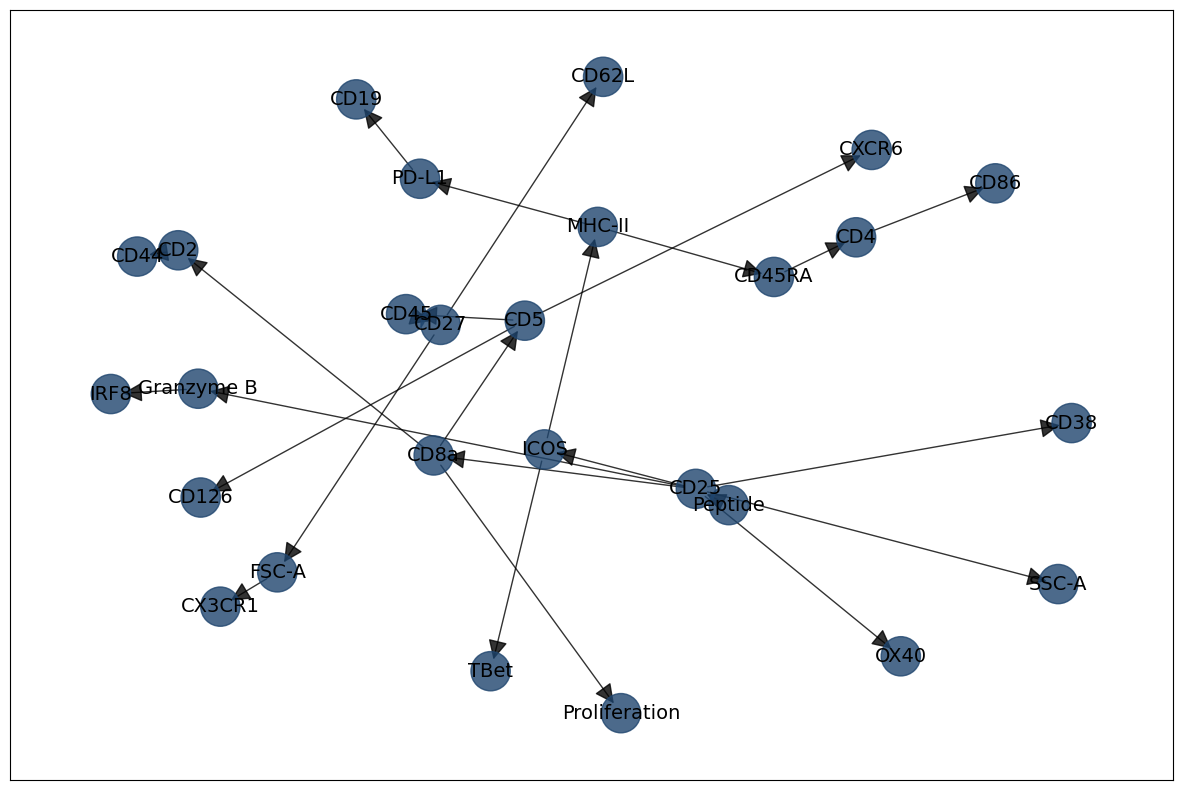

{'fig': <Figure size 1500x1000 with 1 Axes>,
 'ax': <Figure size 1500x1000 with 1 Axes>,
 'pos': {'Peptide': array([ 0.34908683, -0.36982261]),
  'CD25': array([ 0.28656012, -0.32113901]),
  'ICOS': array([-0.00076153, -0.20310316]),
  'CD8a': array([-0.21124843, -0.22115141]),
  'SSC-A': array([ 0.97450991, -0.60607966]),
  'Granzyme B': array([-0.65835526, -0.02142379]),
  'OX40': array([ 0.67568637, -0.82220854]),
  'CD38': array([ 1.        , -0.12424797]),
  'MHC-II': array([0.10020667, 0.46282035]),
  'TBet': array([-0.10319228, -0.86680279]),
  'CD5': array([-0.03821561,  0.18216867]),
  'Proliferation': array([ 0.14428797, -0.99244521]),
  'CD2': array([-0.69633569,  0.39281543]),
  'IRF8': array([-0.82418192, -0.03732695]),
  'PD-L1': array([-0.23721836,  0.60691186]),
  'CD45RA': array([0.43482337, 0.31302622]),
  'CD45': array([-0.26364478,  0.20169763]),
  'CD126': array([-0.65364968, -0.34710055]),
  'CXCR6': array([0.62042958, 0.69316335]),
  'CD44': array([-0.77421358,  

In [7]:
model1 = bn.independence_test(model, df, alpha=0.05, prune=True)
bn.plot(model1)

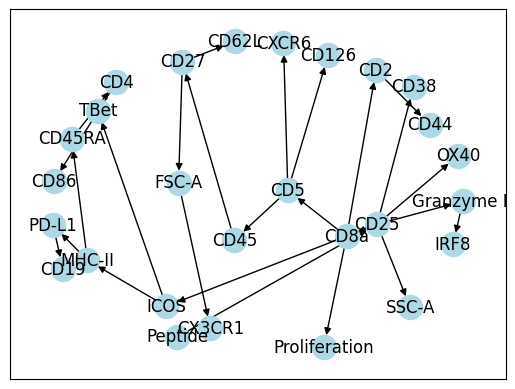

In [8]:
G = nx.from_pandas_adjacency(model1['adjmat'], create_using=nx.DiGraph)
pos = nx.planar_layout(G)
pos = nx.spring_layout(G, k=2, pos=pos)  # Positions of nodes
nx.draw_networkx(G, pos, with_labels=True, node_color='lightblue', node_size=300, arrows=True)

In [9]:
df_raw = bn.import_example(data='titanic')
df_raw

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [10]:
dfhot, dfnum = bn.df2onehot(df_raw)


[df2onehot] >Auto detecting dtypes.


100%|██████████| 12/12 [00:00<00:00, 128.42it/s]


[df2onehot] >Set dtypes in dataframe..


[df2onehot]: 100%|██████████| 12/12 [00:00<00:00, 261.91it/s]

[df2onehot] >Total onehot features: 19


In [11]:
dfhot

,Survived_0,Survived_1,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,SibSp_2,SibSp_3,SibSp_4,Parch_0,Parch_1,Parch_2,Cabin_None,Embarked_C,Embarked_Q,Embarked_S
0,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,True,False,False,True
1,False,True,True,False,False,True,False,False,True,False,False,False,True,False,False,False,True,False,False
2,False,True,False,False,True,True,False,True,False,False,False,False,True,False,False,True,False,False,True
3,False,True,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,True
4,True,False,False,False,True,False,True,True,False,False,False,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,True,False,False,True,False,False,True,True,False,False,False,False,True,False,False,True,False,False,True
887,False,True,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True
888,True,False,False,False,True,True,False,False,True,False,False,False,False,False,True,True,False,False,True
889,False,True,True,False,False,False,True,True,False,False,False,False,True,False,False,False,True,False,False


In [12]:
dfnum

,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Cabin,Embarked
0,0,3,108,1,2,1,523,146,3
1,1,1,190,0,2,1,596,81,1
2,1,3,353,0,1,1,669,146,3
3,1,1,272,0,2,1,49,55,3
4,0,3,15,1,1,1,472,146,3
...,...,...,...,...,...,...,...,...,...
886,0,2,548,1,1,1,101,146,3
887,1,1,303,0,1,1,14,30,3
888,0,3,413,0,2,3,675,146,3
889,1,1,81,1,1,1,8,60,1
